# Lending Club Credit Risk Analysis
## Notebook 2 — Exploratory Data Analysis

**Author:** Jeffrey Symons  
**Date:** July 2026  
**Purpose:** Explore loan performance data to identify risk drivers and data quality issues.

### What this notebook does:
1. Profiles the dataset — nulls, distributions, outliers
2. Bivariate analysis — default rate by key variables
3. Correlation analysis — identify multicollinearity
4. Feature selection — remove redundant columns
5. Save correlation-filtered dataset for modeling

## 1. Imports and Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_rows', 100)

df = pd.read_parquet('lending_club_v2.parquet', engine='fastparquet')

print('Shape:', df.shape)
print('Memory:', df.memory_usage(deep=True).sum() / 1e6, 'MB')

Shape: (1217422, 65)
Memory: 241.051213 MB


## 2. Data Profile

In [2]:
# Full data profile
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'unique_values': df.nunique(),
    'min_values': df.min(numeric_only=True),
    'max_values': df.max(numeric_only=True)
})
print(summary)

                                         dtype  null_count  null_pct  \
acc_open_past_24mths                      Int8           0      0.00   
addr_state                            category           0      0.00   
annual_inc                             float32           0      0.00   
avg_cur_bal                              Int32        4610      0.38   
bc_open_to_buy                           Int32       12609      1.04   
bc_util                                float32       13332      1.10   
collections_12_mths_ex_med                Int8           0      0.00   
credit_age_months                        Int16           0      0.00   
default                                   Int8           0      0.00   
delinq_2yrs                               Int8           0      0.00   
dti                                    float32           0      0.00   
earliest_cr_line                datetime64[us]           0      0.00   
emp_length                            category           0      

## 3. Vintage Coverage Investigation

Three columns share identical null counts (67,527) — investigating.

In [3]:
# Confirm all three are null on exactly the same rows
same_rows = (
    df['num_accts_ever_120_pd'].isnull() &
    df['num_op_rev_tl'].isnull() &
    df['num_tl_op_past_12m'].isnull()
)
print('Rows where all three are null:', same_rows.sum())
print('Rows where only some are null:',
    df[['num_accts_ever_120_pd', 'num_op_rev_tl', 'num_tl_op_past_12m'
       ]].isnull().any(axis=1).sum() - same_rows.sum())

Rows where all three are null: 4591
Rows where only some are null: 0


In [4]:
# Check vintage cutoff
df['issue_d_dt'] = pd.to_datetime(df['issue_d'].astype(str), format='mixed')

vintage_nulls = df.groupby('issue_d_dt')['num_op_rev_tl'].apply(
    lambda x: x.isnull().sum() / len(x) * 100
).reset_index()
vintage_nulls.columns = ['issue_d_dt', 'null_pct']

first_available = vintage_nulls[
    vintage_nulls['null_pct'] < 100]['issue_d_dt'].min()
print('First vintage with data:', first_available)
# Confirmed: pre-2013 vintage coverage issue — drop all three columns

First vintage with data: 2012-08-01 00:00:00


In [5]:
# Drop vintage coverage columns — same issue as Dec 2015 group
df = df.drop(columns=['num_accts_ever_120_pd', 'num_op_rev_tl',
                       'num_tl_op_past_12m', 'issue_d_dt'])
print('Shape after additional vintage drops:', df.shape)

Shape after additional vintage drops: (1217422, 62)


## 4. Date Conversions and Feature Engineering

In [6]:
# Convert date columns
df['issue_d'] = pd.to_datetime(df['issue_d'].astype(str), format='mixed')
df['earliest_cr_line'] = pd.to_datetime(
    df['earliest_cr_line'].astype(str), format='mixed'
)

# Credit age — already in parquet but recalculate for clean notebook
df['credit_age_months'] = (
    (df['issue_d'] - df['earliest_cr_line']).dt.days / 30
).round().astype(int)
df['credit_age_months'] = df['credit_age_months'].clip(upper=480)

# Ever delinquent flag — null means never delinquent
df['ever_delinq'] = df['mths_since_last_delinq'].notna().astype('Int8')

print('Features engineered successfully')

Features engineered successfully


## 5. Baseline Default Rate

In [7]:
default_rate = df['default'].mean() * 100
print(f'Overall default rate: {default_rate:.2f}%')
print(df['default'].value_counts())
print(df['default'].value_counts(normalize=True).mul(100).round(2))

Overall default rate: 20.24%
default
0    971074
1    246348
Name: count, dtype: Int64
default
0   79.76
1   20.24
Name: proportion, dtype: Float64


## 6. Default Rate by Grade

  grade  default_rate
0     A          6.00
1     B         13.44
2     C         22.61
3     D         30.74
4     E         39.13
5     F         45.91
6     G         50.73


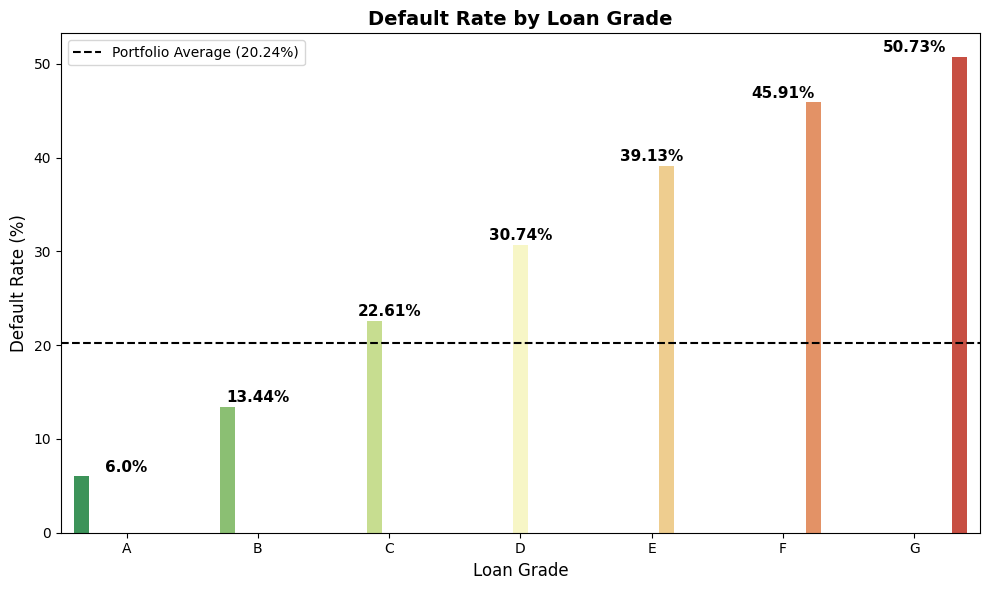

In [12]:
grade_default = df.groupby('grade', observed=True)['default'].mean(
).mul(100).round(2).reset_index()
grade_default.columns = ['grade', 'default_rate']
print(grade_default)

plt.figure(figsize=(10, 6))
sns.barplot(data=grade_default, x='grade', y='default_rate',
            hue='grade', palette='RdYlGn_r', legend=False)
plt.axhline(y=default_rate, color='black', linestyle='--',
            linewidth=1.5, label=f'Portfolio Average ({default_rate:.2f}%)')
for i, row in grade_default.iterrows():
    plt.text(i, row['default_rate'] + 0.5, f"{row['default_rate']}%",
             ha='center', fontsize=11, fontweight='bold')
plt.title('Default Rate by Loan Grade', fontsize=14, fontweight='bold')
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('charts/default_rate_by_grade.png', dpi=150)
plt.show()

## 7. Default Rate by Term

   term  default_rate
0    36         16.21
1    60         33.03


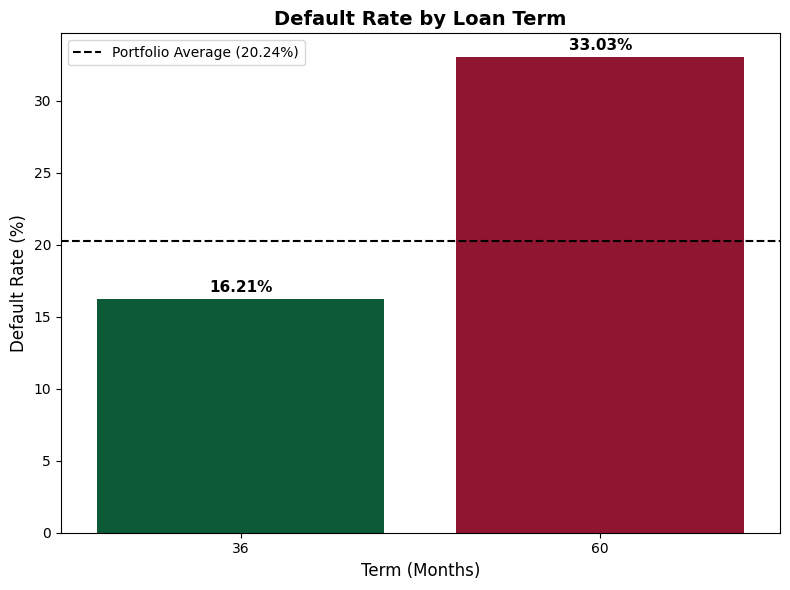

In [13]:
term_default = df.groupby('term', observed=True)['default'].mean(
).mul(100).round(2).reset_index()
term_default.columns = ['term', 'default_rate']
print(term_default)

plt.figure(figsize=(8, 6))
sns.barplot(data=term_default, x='term', y='default_rate',
            hue='term', palette='RdYlGn_r', legend=False)
plt.axhline(y=default_rate, color='black', linestyle='--',
            linewidth=1.5, label=f'Portfolio Average ({default_rate:.2f}%)')
for i, row in term_default.iterrows():
    plt.text(i, row['default_rate'] + 0.5, f"{row['default_rate']}%",
             ha='center', fontsize=11, fontweight='bold')
plt.title('Default Rate by Loan Term', fontsize=14, fontweight='bold')
plt.xlabel('Term (Months)', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('charts/default_rate_by_term.png', dpi=150)
plt.show()

## 8. Default Rate by Purpose

               purpose   count  default_rate
0       small_business   12150         30.31
1     renewable_energy     761         24.05
2               moving    8212         23.73
3                house    6200         22.24
4              medical   13627         22.07
5                other   68131         21.40
6   debt_consolidation  711972         21.38
7       major_purchase   25012         19.56
8             vacation    8063         19.35
9     home_improvement   78256         18.14
10         credit_card  272211         17.18
11                 car   11882         15.23
12             wedding     944         14.83
13         educational       1          0.00


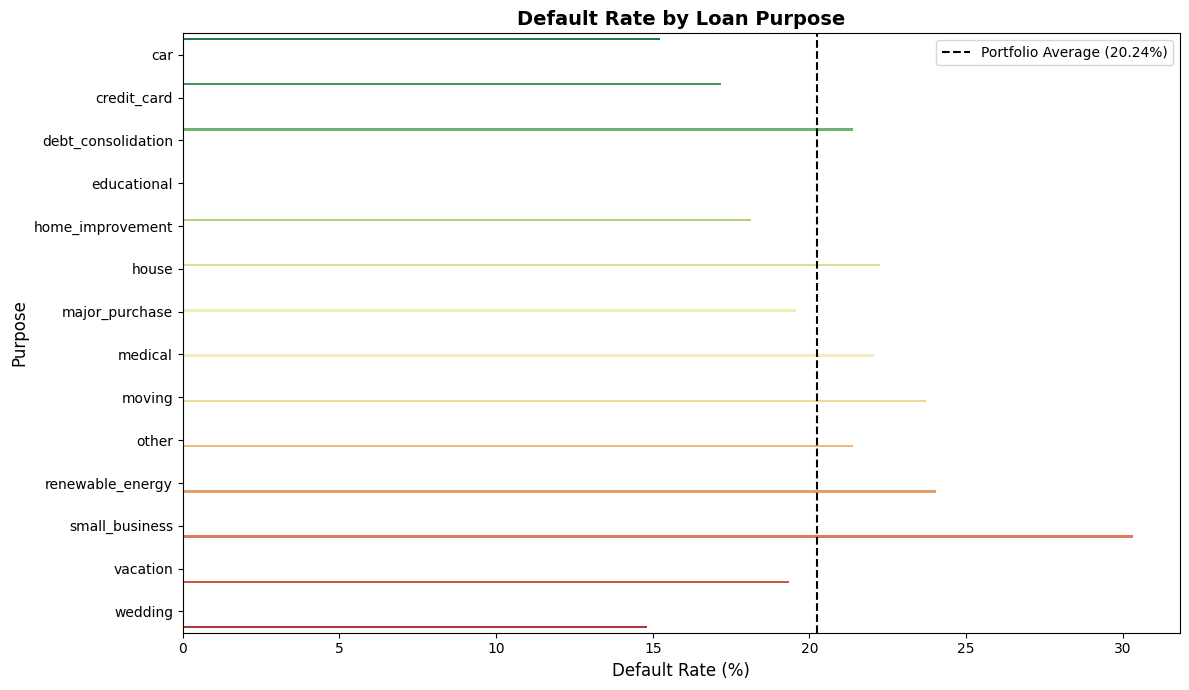

In [14]:
purpose_summary = df.groupby('purpose', observed=True).agg(
    count=('default', 'count'),
    default_rate=('default', lambda x: round(x.mean() * 100, 2))
).sort_values('default_rate', ascending=False).reset_index()
print(purpose_summary)

plt.figure(figsize=(12, 7))
sns.barplot(data=purpose_summary, x='default_rate', y='purpose',
            hue='purpose', palette='RdYlGn_r', legend=False)
plt.axvline(x=default_rate, color='black', linestyle='--',
            linewidth=1.5, label=f'Portfolio Average ({default_rate:.2f}%)')
plt.title('Default Rate by Loan Purpose', fontsize=14, fontweight='bold')
plt.xlabel('Default Rate (%)', fontsize=12)
plt.ylabel('Purpose', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('charts/default_rate_by_purpose.png', dpi=150)
plt.show()

## 9. Vintage Analysis

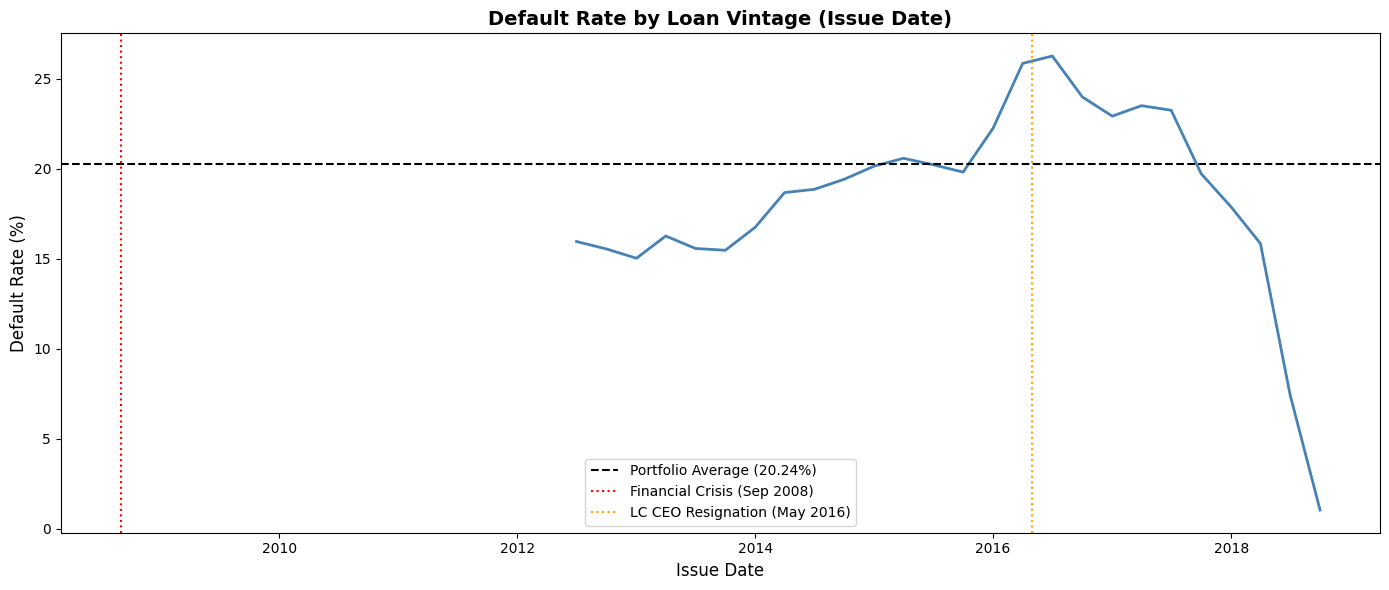

In [15]:
issued_default = df.groupby(
    df['issue_d'].dt.to_period('Q')
)['default'].apply(
    lambda x: x.sum() / len(x) * 100
).reset_index()
issued_default.columns = ['issue_d', 'default_rate']
issued_default['issue_d'] = issued_default['issue_d'].dt.to_timestamp()

plt.figure(figsize=(14, 6))
plt.plot(issued_default['issue_d'], issued_default['default_rate'],
         color='steelblue', linewidth=2)
plt.axhline(y=default_rate, color='black', linestyle='--',
            linewidth=1.5, label=f'Portfolio Average ({default_rate:.2f}%)')
plt.axvline(x=pd.Timestamp('2008-09-01'), color='red', linestyle=':',
            linewidth=1.5, label='Financial Crisis (Sep 2008)')
plt.axvline(x=pd.Timestamp('2016-05-01'), color='orange', linestyle=':',
            linewidth=1.5, label='LC CEO Resignation (May 2016)')
plt.title('Default Rate by Loan Vintage (Issue Date)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Issue Date', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('charts/default_rate_by_vintage.png', dpi=150)
plt.show()

## 10. Additional EDA — Home Ownership, Verification, DTI, Income

In [16]:
# Default rate by home ownership
home_summary = df.groupby('home_ownership', observed=True).agg(
    count=('default', 'count'),
    default_rate=('default', lambda x: round(x.mean() * 100, 2))
).sort_values('default_rate', ascending=False).reset_index()
print('Home ownership:')
print(home_summary)

# Default rate by verification status
verif_summary = df.groupby('verification_status', observed=True).agg(
    count=('default', 'count'),
    default_rate=('default', lambda x: round(x.mean() * 100, 2))
).sort_values('default_rate', ascending=False).reset_index()
print('\nVerification status (confounding variable):')
print(verif_summary)

Home ownership:
  home_ownership   count  default_rate
0           RENT  482293         23.69
1            OWN  132808         20.76
2            ANY     267         19.48
3          OTHER      45         17.78
4       MORTGAGE  601966         17.35
5           NONE      43         16.28

Verification status (confounding variable):
  verification_status   count  default_rate
0            Verified  377354         24.19
1     Source Verified  480310         21.26
2        Not Verified  359758         14.71


  dti_bucket   count  default_rate
0        0-4   57218         14.73
1        5-9  159328         15.00
2      10-14  246881         16.72
3      15-19  262533         19.30
4      20-24  219177         22.07
5      25-29  157226         25.20
6      30-34   87442         28.88
7      35-39   25390         31.67
8      40-44    1071         39.59
9      45-49     597         42.71


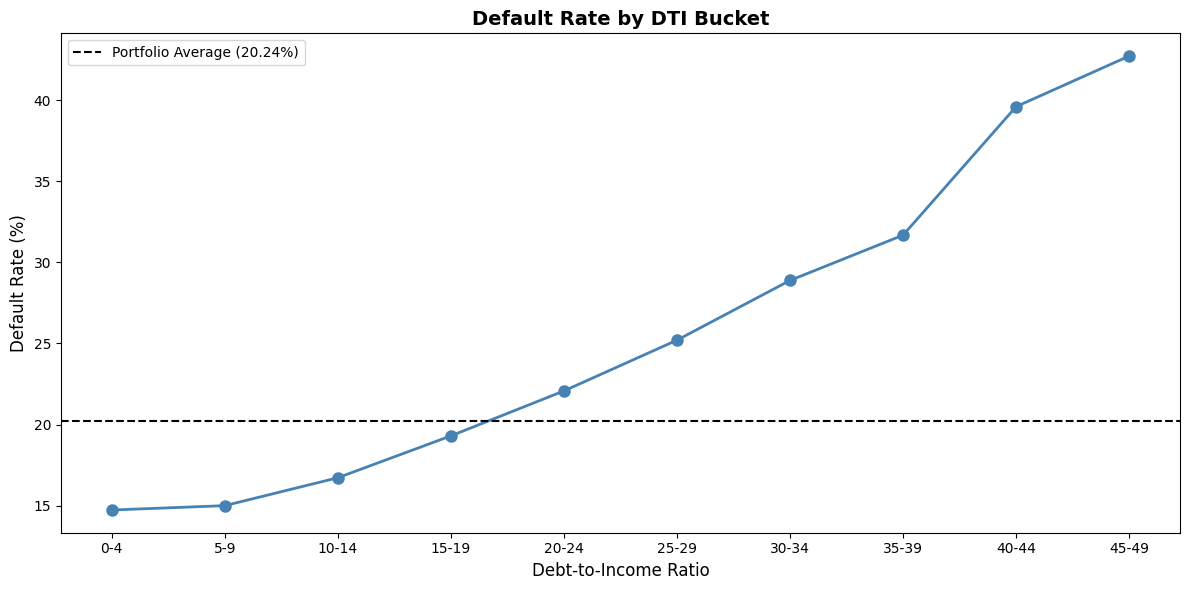

In [17]:
# DTI bucketed analysis
df['dti_bucket'] = pd.cut(df['dti'], bins=range(0, 55, 5),
    labels=['0-4','5-9','10-14','15-19','20-24',
            '25-29','30-34','35-39','40-44','45-49'])

dti_summary = df.groupby('dti_bucket', observed=True).agg(
    count=('default', 'count'),
    default_rate=('default', lambda x: round(x.mean() * 100, 2))
).reset_index()
print(dti_summary)

plt.figure(figsize=(12, 6))
plt.plot(dti_summary['dti_bucket'], dti_summary['default_rate'],
         marker='o', color='steelblue', linewidth=2, markersize=8)
plt.axhline(y=default_rate, color='black', linestyle='--',
            linewidth=1.5, label=f'Portfolio Average ({default_rate:.2f}%)')
plt.title('Default Rate by DTI Bucket', fontsize=14, fontweight='bold')
plt.xlabel('Debt-to-Income Ratio', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('charts/default_rate_by_dti.png', dpi=150)
plt.show()

## 11. Correlation Heatmap and Feature Selection

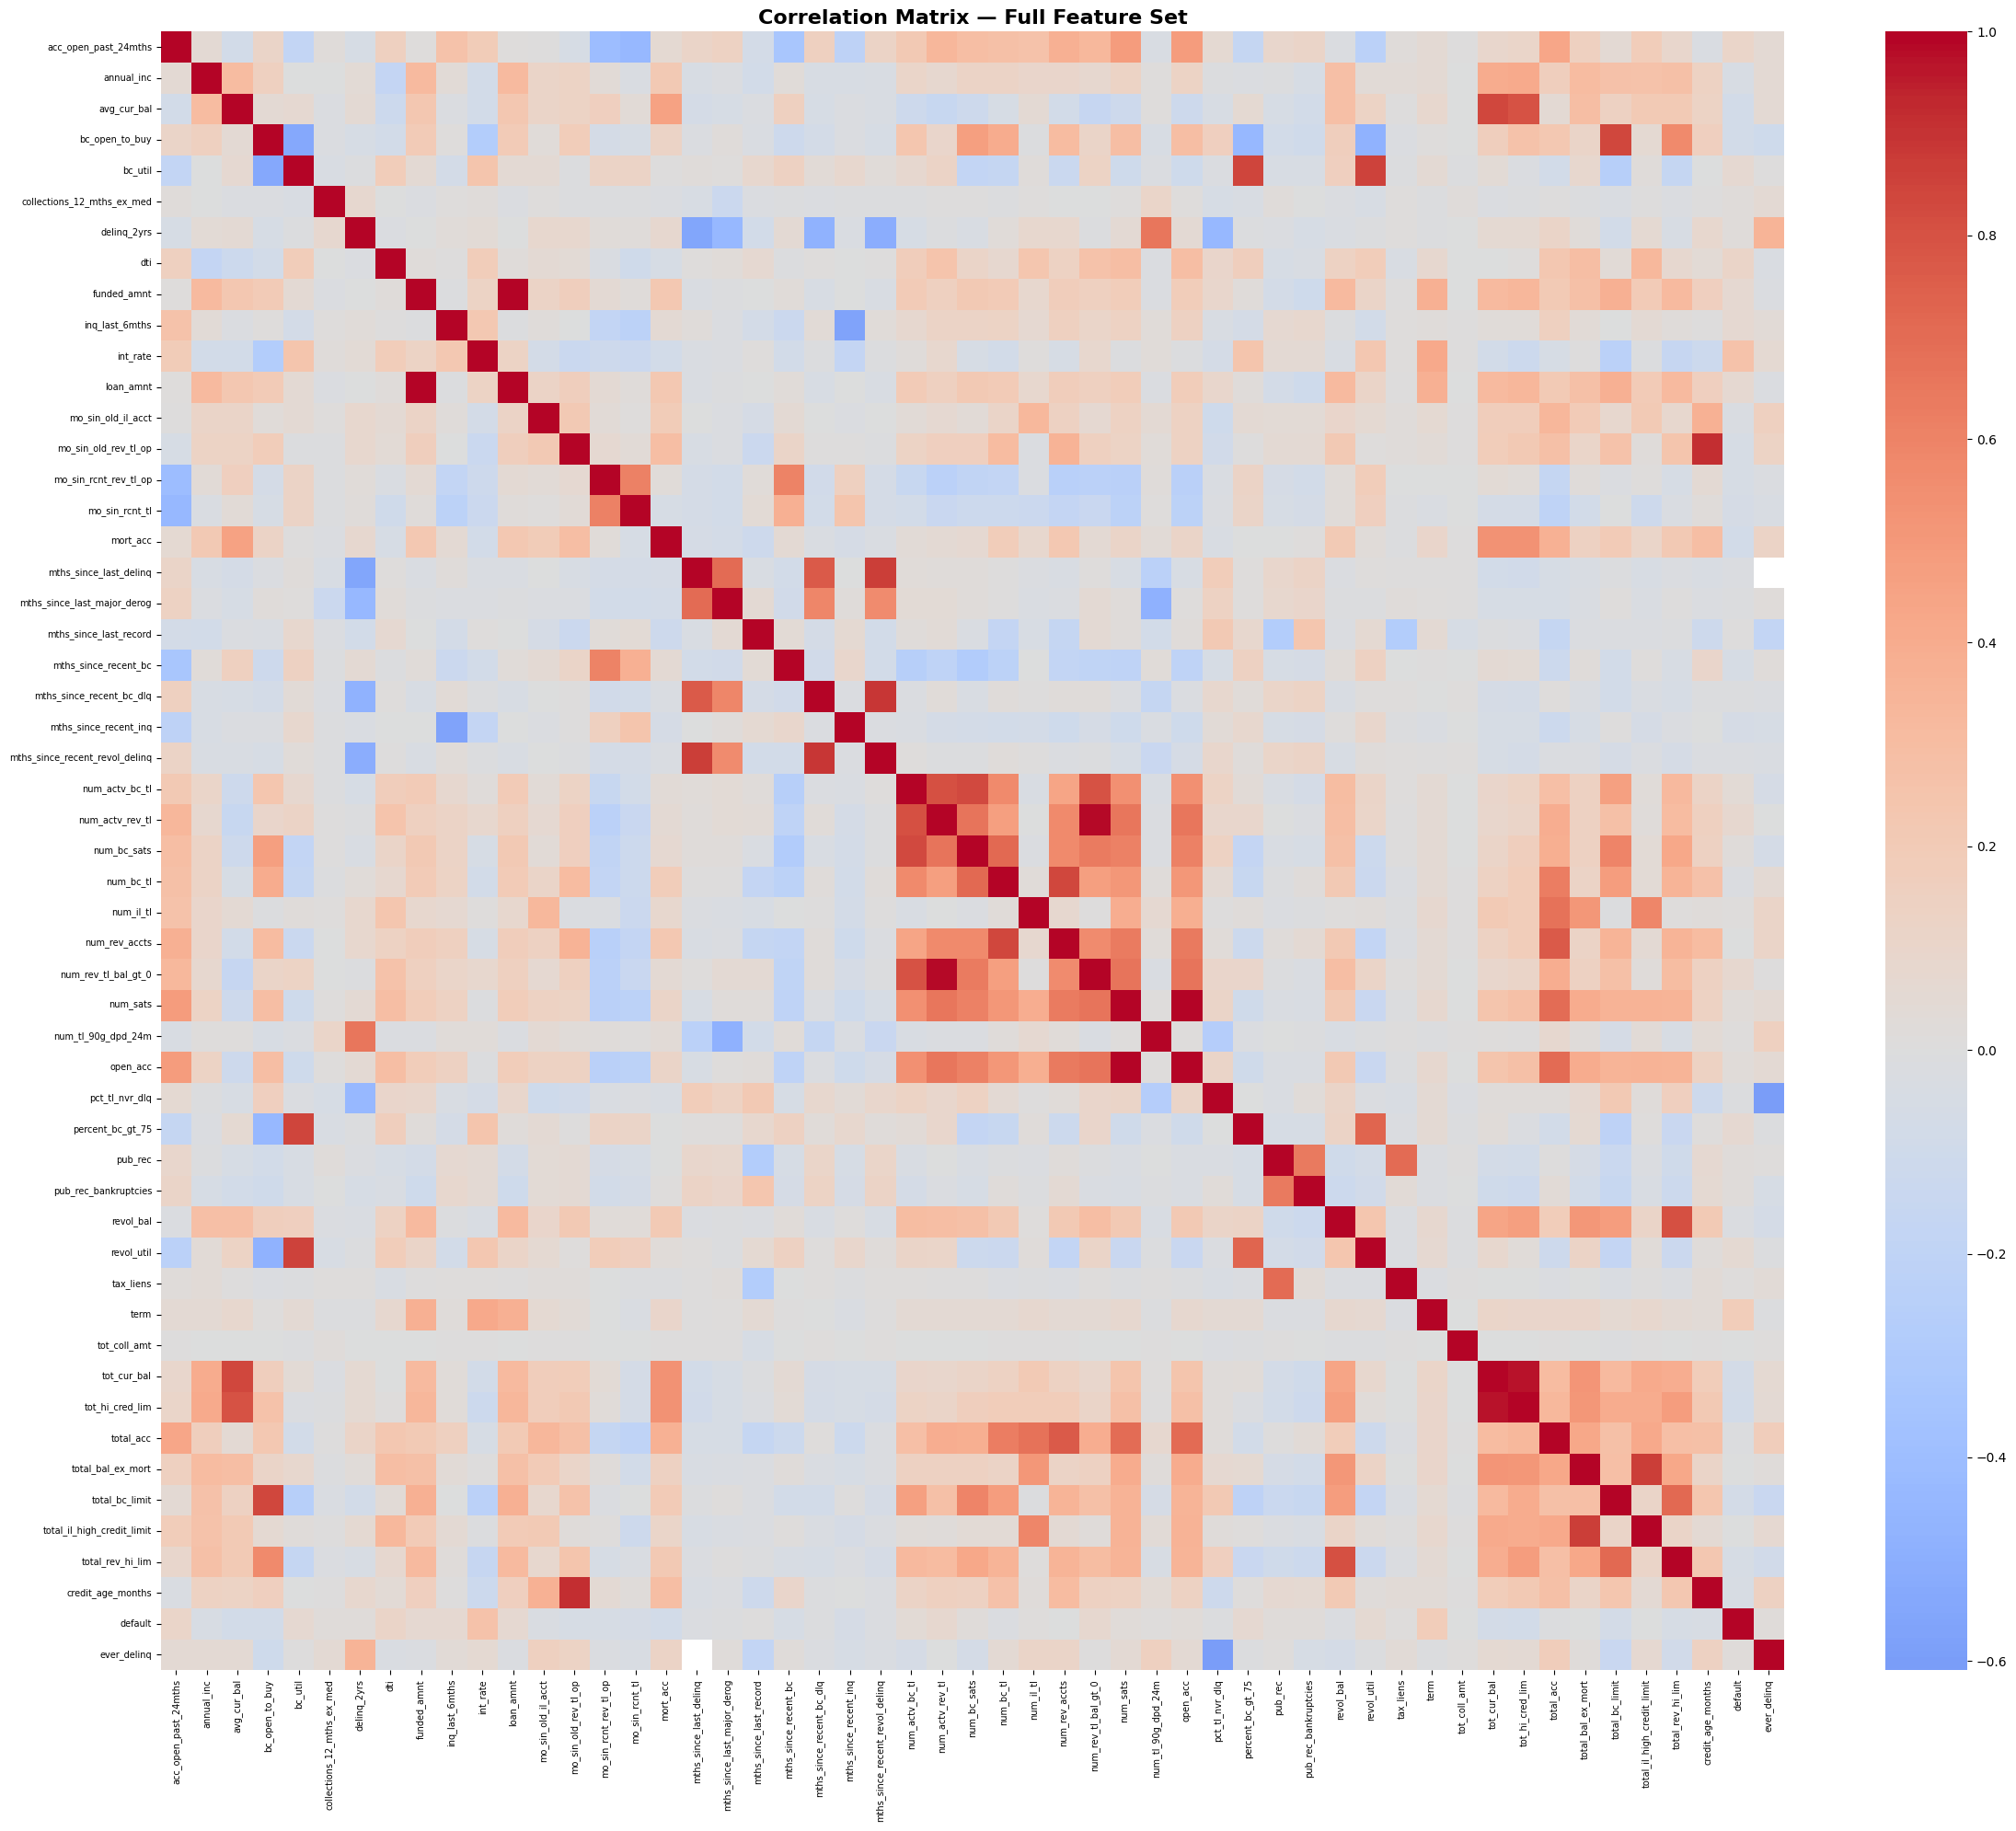

In [18]:
numeric_cols = df.select_dtypes(
    include=['Int8', 'Int16', 'Int32', 'Float32', 'int64', 'float64']
).columns.tolist()

plt.figure(figsize=(24, 20))
sns.heatmap(df[numeric_cols].corr(), annot=False,
            cmap='coolwarm', center=0, linewidths=0)
plt.title('Correlation Matrix — Full Feature Set',
          fontsize=16, fontweight='bold')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('charts/correlation_heatmap_v3.png', dpi=150)
plt.show()

In [19]:
# Correlations with default
default_corr = df[numeric_cols].corr()['default'].drop('default'
    ).abs().sort_values()
print('Correlations with default:')
print(default_corr)

# High multicollinearity pairs
corr_matrix = df[numeric_cols].corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr = upper.stack().reset_index()
high_corr.columns = ['var1', 'var2', 'correlation']
high_corr = high_corr[
    high_corr['correlation'] > 0.70
].sort_values('correlation', ascending=False)
print('\nHigh multicollinearity pairs (>0.70):')
print(high_corr.to_string(index=False))

Correlations with default:
total_il_high_credit_limit       0.00
tot_coll_amt                     0.00
total_bal_ex_mort                0.00
num_rev_accts                    0.00
mths_since_last_major_derog      0.01
mths_since_last_record           0.01
num_il_tl                        0.01
tax_liens                        0.01
pct_tl_nvr_dlq                   0.01
num_tl_90g_dpd_24m               0.01
total_acc                        0.01
mths_since_recent_bc_dlq         0.01
mths_since_last_delinq           0.01
mths_since_recent_revol_delinq   0.01
num_bc_sats                      0.02
ever_delinq                      0.02
collections_12_mths_ex_med       0.02
num_bc_tl                        0.02
delinq_2yrs                      0.02
revol_bal                        0.02
pub_rec_bankruptcies             0.02
pub_rec                          0.02
mo_sin_old_il_acct               0.03
num_sats                         0.03
open_acc                         0.03
credit_age_months      


High multicollinearity pairs (>0.70):
                    var1                           var2  correlation
             funded_amnt                      loan_amnt         1.00
                num_sats                       open_acc         1.00
         num_actv_rev_tl            num_rev_tl_bal_gt_0         0.98
             tot_cur_bal                tot_hi_cred_lim         0.97
    mo_sin_old_rev_tl_op              credit_age_months         0.92
mths_since_recent_bc_dlq mths_since_recent_revol_delinq         0.89
       total_bal_ex_mort     total_il_high_credit_limit         0.87
  mths_since_last_delinq mths_since_recent_revol_delinq         0.87
                 bc_util                     revol_util         0.85
                 bc_util               percent_bc_gt_75         0.84
               num_bc_tl                  num_rev_accts         0.84
          bc_open_to_buy                 total_bc_limit         0.84
             avg_cur_bal                    tot_cur_bal         

In [21]:
# Drop columns based on correlation analysis
# Rule: for each correlated pair, keep the variable with higher correlation to default
# Manual overrides: keep funded_amnt (actual credit extended), 
#                   keep credit_age_months (engineered, interpretable)
#                   keep total_acc (credit breadth)

drop_corr_cols = [
    'loan_amnt',                       # keep funded_amnt (actual amount)
    'num_sats',                        # 1.00 with open_acc
    'num_rev_tl_bal_gt_0',            # 0.98 with num_actv_rev_tl
    'tot_cur_bal',                     # 0.84 with avg_cur_bal
    'tot_hi_cred_lim',                # 0.80 with avg_cur_bal
    'mo_sin_old_rev_tl_op',           # 0.92 with credit_age_months
    'mths_since_recent_bc_dlq',       # 0.89 with mths_since_recent_revol_delinq
    'mths_since_recent_revol_delinq', # 0.87 with mths_since_last_delinq
    'total_il_high_credit_limit',     # 0.87 with total_bal_ex_mort
    'revol_util',                     # 0.85 with bc_util
    'percent_bc_gt_75',               # 0.84 with bc_util
    'total_bc_limit',                 # 0.84 with bc_open_to_buy
    'num_rev_accts',                  # 0.84 with num_bc_tl
    'open_acc',                       # 0.83 with num_op_rev_tl
    'num_bc_sats',                    # 0.83 with num_actv_bc_tl
    'num_actv_bc_tl',                 # 0.81 with num_actv_rev_tl
    'revol_bal',                      # 0.81 with total_rev_hi_lim
    # 'num_op_rev_tl',                  # 0.79-0.83 multiple conflicts
    'mths_since_last_major_derog',    # 0.71 with mths_since_last_delinq
    'tax_liens',                      # 0.70 with pub_rec
    # 'num_tl_op_past_12m',             # 0.76 with acc_open_past_24mths
]

df = df.drop(columns=drop_corr_cols)
print('Shape after correlation drops:', df.shape)

Shape after correlation drops: (1217422, 45)


In [22]:
# Drop low signal columns (correlation with default < 0.01, no domain rationale)
drop_low_signal = [
    'tot_coll_amt',           # 0.00 correlation with default
    'total_bal_ex_mort',      # 0.00 correlation with default
    'mths_since_last_record', # 0.01, plus 82% null
    'num_il_tl',              # 0.01
    'pct_tl_nvr_dlq',         # 0.01
    'total_acc'               # 0.01
]
df = df.drop(columns=drop_low_signal)
print('Shape after low signal drops:', df.shape)
print('Final columns:', df.columns.tolist())

Shape after low signal drops: (1217422, 39)
Final columns: ['acc_open_past_24mths', 'addr_state', 'annual_inc', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'collections_12_mths_ex_med', 'delinq_2yrs', 'dti', 'earliest_cr_line', 'emp_length', 'funded_amnt', 'grade', 'home_ownership', 'inq_last_6mths', 'int_rate', 'issue_d', 'loan_status', 'mo_sin_old_il_acct', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_last_delinq', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_actv_rev_tl', 'num_bc_tl', 'num_tl_90g_dpd_24m', 'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'sub_grade', 'term', 'total_rev_hi_lim', 'verification_status', 'credit_age_months', 'default', 'ever_delinq', 'dti_bucket']


## 12. Save Correlation-Filtered Dataset

In [23]:
df.to_parquet('lending_club_v2_correlated.parquet',
              index=False, engine='fastparquet')

print('Saved successfully')
print('Final shape:', df.shape)
print('Final memory:', df.memory_usage(deep=True).sum() / 1e6, 'MB')

Saved successfully
Final shape: (1217422, 39)
Final memory: 136.353903 MB


## 13. Export Tableau Dataset

In [24]:
# Note: run after modeling notebook to include default_prob and risk_tier
# This cell is a placeholder — see modeling notebook for full export
print('Tableau export done in modeling notebook after model scores are generated')

Tableau export done in modeling notebook after model scores are generated
